In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Ustawienia estetyki wykresów

In [26]:
sns.set_theme(style="whitegrid")

# 2. Bezpieczne ładowanie danych z obsługą UTF-8

In [27]:
sciezki = ['../data/raw/claims_event_log.csv', '04_claims_process_optimization/data/raw/claims_event_log.csv', 'claims_event_log.csv']
df = None

for s in sciezki:
    try:
        df = pd.read_csv(s, encoding='utf-8-sig')
        df.columns = df.columns.str.strip()
        print(f"Załadowano logi procesowe z: {s}\n")
        break
    except FileNotFoundError:
        continue

if df is None:
    raise FileNotFoundError("Błąd: Nie znaleziono pliku claims_event_log.csv!")

Załadowano logi procesowe z: claims_event_log.csv



# 3. TRANSFORMOWANIE DANYCH (Process Mining / Lead Time Calculation)

In [28]:
# Konwersja znacznika czasu na obiekt datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Sortujemy dane, aby mieć pewność chronologii
df = df.sort_values(by=['claim_id', 'timestamp'])

# Obliczamy czas trwania danego etapu (różnica między kolejnymi wierszami dla tego samego claim_id)
df['duration_hours'] = df.groupby('claim_id')['timestamp'].diff().dt.total_seconds() / 3600

# Ponieważ .diff() daje NaN dla pierwszego kroku (BOK), przesuwamy przypisanie czasu do działu, 
# który ten czas zużył na procesowanie (BOK -> Jakość -> Produkcja -> Logistyka)
df['duration_hours'] = df.groupby('claim_id')['duration_hours'].shift(-1)

# Usuwamy ostatnie kroki (wysyłka zakończona), które nie mają dalszego kroku
df_clean = df.dropna(subset=['duration_hours']).copy()

# Wyświetlenie raportu tabelarycznego dla średniego czasu per dział
summary = df_clean.groupby('department')['duration_hours'].agg(['mean', 'max', 'min']).round(1)
print("ŚREDNI CZAS PROCESOWANIA REKLAMACJI (w godzinach):")
print(summary, "\n")

ŚREDNI CZAS PROCESOWANIA REKLAMACJI (w godzinach):
            mean   max   min
department                  
BOK         45.9  98.5   2.8
Jakosc      15.2  21.8   2.5
Produkcja   24.7  29.3  17.8 



# 4. WIZUALIZACJA: Box Plot obrazujący wąskie gardło procesu

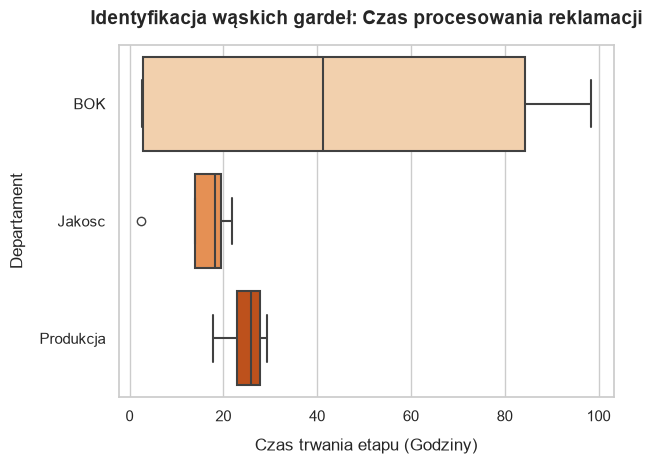

In [29]:
# Tworzymy wykres pudełkowy
sns.boxplot(
    x='duration_hours', 
    y='department', 
    data=df_clean, 
    palette='Oranges', 
    hue='department',
    legend=False,
    linewidth=1.5
)

plt.title('Identyfikacja wąskich gardeł: Czas procesowania reklamacji', fontsize=14, weight='bold', pad=15)
plt.xlabel('Czas trwania etapu (Godziny)', fontsize=12, labelpad=10)
plt.ylabel('Departament', fontsize=12, labelpad=10)
plt.tight_layout()

# Zapis wykresu
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/claims_bottleneck_boxplot.png', dpi=300)
plt.show()